# Week 1 — Day 3: Baseline Machine Learning Model

## 1. Introduction
## 2. Import Libraries
## 3. Load Processed Dataset
## 4. Dataset Overview
## 5. Feature and Target Separation
## 6. Train-Test Split
## 7. Feature Scaling
## 8. Train Baseline Logistic Regression Model
## 9. Model Evaluation
## 10. Confusion Matrix
## 11. ROC-AUC Score
## 12. Medical Interpretation
## 13. Conclusion

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [4]:
data_path = Path("../data/processed/day2_patient_level_features.csv")

df = pd.read_csv(data_path)

df.head()

,Patient_ID,HR_mean,HR_max,HR_min,O2Sat_mean,O2Sat_min,Temp_mean,Temp_max,SBP_mean,SBP_min,MAP_mean,MAP_min,Resp_mean,Resp_max,Age_first,Gender_first,ICULOS_max,SepsisLabel_max
0,p000001,101.907407,117.0,76.0,91.453704,85.0,36.735185,37.44,127.870370,78.0,88.321111,44.00,24.555556,32.0,83.14,0,54,0
1,p000002,62.173913,94.0,54.0,97.043478,94.0,36.206087,37.00,129.043478,114.0,67.239130,50.50,14.630435,27.0,75.91,0,23,0
2,p000003,79.968750,93.0,68.0,95.375000,91.0,37.465000,38.61,139.760417,121.0,81.149167,62.67,25.302083,40.0,45.82,0,48,0
3,p000004,102.172414,113.0,89.0,98.189655,95.5,36.463103,37.00,113.017241,90.0,67.063103,34.00,18.758621,26.0,65.71,0,29,0
4,p000005,76.604167,88.0,61.0,97.677083,96.0,37.072292,37.33,135.072917,114.0,90.364583,73.00,15.447917,21.0,28.09,1,49,0


In [5]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns)

Dataset shape: (100, 18)
Columns:
Index(['Patient_ID', 'HR_mean', 'HR_max', 'HR_min', 'O2Sat_mean', 'O2Sat_min',
       'Temp_mean', 'Temp_max', 'SBP_mean', 'SBP_min', 'MAP_mean', 'MAP_min',
       'Resp_mean', 'Resp_max', 'Age_first', 'Gender_first', 'ICULOS_max',
       'SepsisLabel_max'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Patient_ID       100 non-null    object 
 1   HR_mean          100 non-null    float64
 2   HR_max           100 non-null    float64
 3   HR_min           100 non-null    float64
 4   O2Sat_mean       100 non-null    float64
 5   O2Sat_min        100 non-null    float64
 6   Temp_mean        100 non-null    float64
 7   Temp_max         100 non-null    float64
 8   SBP_mean         100 non-null    float64
 9   SBP_min          100 non-null    float64
 10  MAP_mean         100 non-null    float64
 11  MAP_min          100 non-null    float64
 12  Resp_mean        100 non-null    float64
 13  Resp_max         100 non-null    float64
 14  Age_first        100 non-null    float64
 15  Gender_first     100 non-null    int64  
 16  ICULOS_max       100 non-null    int64  
 17  SepsisLabel_max  

In [8]:
df.columns.tolist()

['Patient_ID',
 'HR_mean',
 'HR_max',
 'HR_min',
 'O2Sat_mean',
 'O2Sat_min',
 'Temp_mean',
 'Temp_max',
 'SBP_mean',
 'SBP_min',
 'MAP_mean',
 'MAP_min',
 'Resp_mean',
 'Resp_max',
 'Age_first',
 'Gender_first',
 'ICULOS_max',
 'SepsisLabel_max']

In [9]:
df = df.rename(columns={
    "SepsisLabel_max": "SepsisLabel"
})

df.columns.tolist()

['Patient_ID',
 'HR_mean',
 'HR_max',
 'HR_min',
 'O2Sat_mean',
 'O2Sat_min',
 'Temp_mean',
 'Temp_max',
 'SBP_mean',
 'SBP_min',
 'MAP_mean',
 'MAP_min',
 'Resp_mean',
 'Resp_max',
 'Age_first',
 'Gender_first',
 'ICULOS_max',
 'SepsisLabel']

In [10]:
df["SepsisLabel"].value_counts()

SepsisLabel
0    86
1    14
Name: count, dtype: int64

In [11]:
df["SepsisLabel"].value_counts(normalize=True) * 100

SepsisLabel
0    86.0
1    14.0
Name: proportion, dtype: float64

The dataset is patient-level, meaning each row represents one ICU patient.

The target variable is `SepsisLabel`:
- 0 = patient did not develop sepsis
- 1 = patient developed sepsis

Because sepsis cases are usually less frequent, class imbalance is expected.

In [12]:
X = df.drop(columns=["Patient_ID", "SepsisLabel"])
y = df["SepsisLabel"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (100, 16)
Target shape: (100,)


In [13]:
X = df.drop(columns=["Patient_ID", "SepsisLabel"])
y = df["SepsisLabel"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (100, 16)
Target shape: (100,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (80, 16)
Testing set: (20, 16)


The dataset is split into training and testing sets.

Stratification is used to preserve the same proportion of septic and non-septic patients in both sets.

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling is applied because Logistic Regression is sensitive to the magnitude of numerical features.

The scaler is fitted only on the training data to avoid data leakage.

In [16]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

Logistic Regression is used as the first baseline model because it is simple, interpretable, and commonly used in medical prediction tasks.

The parameter `class_weight="balanced"` is used because sepsis cases are less frequent than non-sepsis cases.

In [17]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.5000
Precision: 0.1111
Recall:    0.3333
F1-score:  0.1667
ROC-AUC:   0.4706


In medical early warning systems, recall is especially important because missing a high-risk patient can be dangerous.

However, precision is also important because too many false alarms can lead to alarm fatigue in clinical settings.

In [19]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.82      0.53      0.64        17
           1       0.11      0.33      0.17         3

    accuracy                           0.50        20
   macro avg       0.46      0.43      0.40        20
weighted avg       0.71      0.50      0.57        20



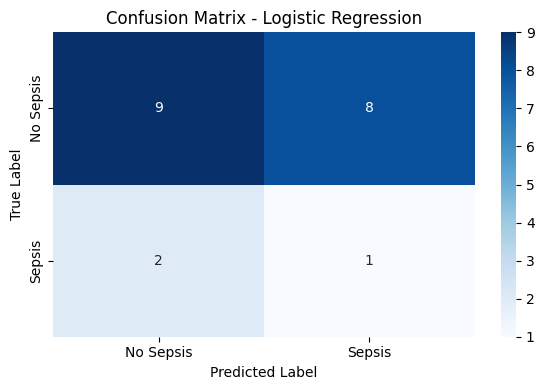

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Sepsis", "Sepsis"],
    yticklabels=["No Sepsis", "Sepsis"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

The confusion matrix shows:
- True negatives: correctly predicted non-sepsis patients
- False positives: non-sepsis patients incorrectly predicted as sepsis
- False negatives: sepsis patients missed by the model
- True positives: correctly predicted sepsis patients

For medical early warning systems, false negatives are especially concerning.

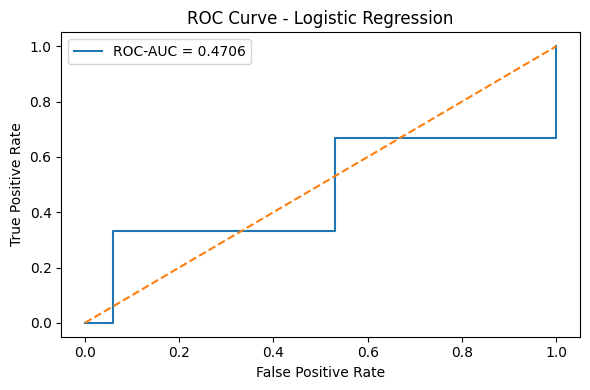

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
2,HR_min,1.857234,1.857234
1,HR_max,-1.034056,1.034056
0,HR_mean,-0.716089,0.716089
15,ICULOS_max,0.622089,0.622089
13,Age_first,-0.530208,0.530208
14,Gender_first,-0.435821,0.435821
7,SBP_mean,0.339827,0.339827
5,Temp_mean,0.318638,0.318638
12,Resp_max,-0.289334,0.289334
9,MAP_mean,-0.288931,0.288931


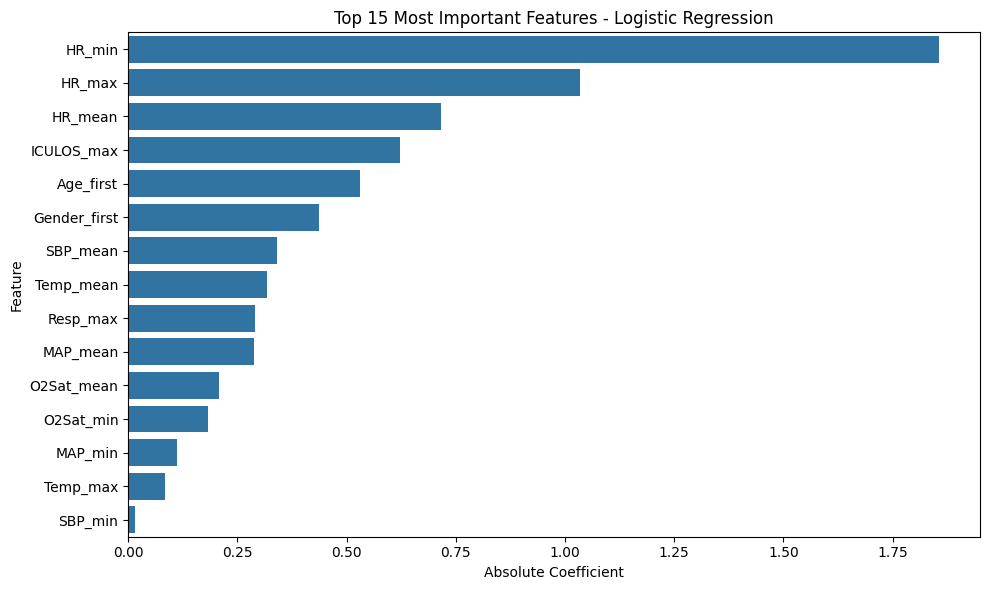

In [23]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x="Absolute_Coefficient",
    y="Feature"
)

plt.title("Top 15 Most Important Features - Logistic Regression")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

Logistic Regression coefficients provide a first interpretable view of which features influence the prediction.

Larger absolute coefficients indicate stronger influence on the model prediction.

## Medical Interpretation

The baseline model uses aggregated ICU features such as heart rate, oxygen saturation, temperature, blood pressure, respiratory rate, age, and ICU length of stay.

These variables are clinically relevant because sepsis is often associated with:
- increased heart rate
- abnormal temperature
- respiratory changes
- reduced blood pressure
- longer ICU stay
- signs of physiological instability

This model should not be considered clinically valid yet. It is only an initial baseline used to test the machine learning pipeline.

In [24]:
results_path = Path("../results")
results_path.mkdir(parents=True, exist_ok=True)

In [25]:
metrics = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "roc_auc": roc_auc
}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv(results_path / "day3_baseline_model_metrics.csv", index=False)

metrics_df

,accuracy,precision,recall,f1_score,roc_auc
0,0.5,0.111111,0.333333,0.166667,0.470588


In [26]:
feature_importance.to_csv(
    results_path / "day3_logistic_regression_feature_importance.csv",
    index=False
)